# TCC — Previsão de Trajetórias de Furacões com LSTM
Notebook consolidado com todas as etapas do pipeline metodológico (Figura 2 e Figura 3 do artigo).

**Versão atualizada** — inclui as correções feitas ao longo do desenvolvimento:
- Divisão treino/teste com contexto suficiente para gerar janelas (Etapa 7)
- Normalização das variáveis de entrada (Etapa 7)
- Camada `Input()` explícita no lugar de `input_shape` (Etapas 8 e 9)
- Random Search avaliado em conjunto de validação, não em treino (Etapa 9)
- Avaliação com baseline de persistência + métricas sobre Δlat/Δlon + MAE (Etapa 10)
- Visualização de trajetória real vs. prevista com previsão recursiva multi-passo (Etapa 10.1)
- SHAP com `KernelExplainer` (compatível com LSTM) e sinal preservado (Etapa 11)

1. Coleta e seleção de dados
2. Limpeza dos dados
3. Formatação e padronização
4. Pré-processamento (ordenação, filtro de trajetórias curtas, cálculo de Δlat/Δlon)
5. Análise exploratória dos dados (EDA)
6. Análise de Componentes Principais (PCA)
7. Preparação das janelas temporais e divisão treino/teste
8. Modelagem preditiva (LSTM)
9. Busca de hiperparâmetros (Random Search)
10. Avaliação de desempenho (RRMSE, MAPE, MAE)
    - 10.1 Visualização: trajetória real vs. prevista
11. Interpretabilidade (SHAP)

**Ajuste os caminhos na célula de configuração abaixo antes de rodar.**

## 0. Configuração e imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Ajuste esta pasta para onde estão/ficarão seus datasets
PASTA_DATASETS = r"C:\Users\dorfb\OneDrive\Documentos\TCC\datasets"

CAMINHO_BRUTO        = os.path.join(PASTA_DATASETS, "ibtracs.ALL.list.v04r01.csv")
CAMINHO_USA          = os.path.join(PASTA_DATASETS, "ibtracs_USA.csv")
CAMINHO_USA_LIMPO    = os.path.join(PASTA_DATASETS, "ibtracs_USA_limpo.csv")
CAMINHO_USA_FORMAT   = os.path.join(PASTA_DATASETS, "ibtracs_USA_formatado.csv")
CAMINHO_USA_PREPROC  = os.path.join(PASTA_DATASETS, "ibtracs_USA_preprocessado.csv")

pd.set_option('display.max_columns', 50)

## 1. Coleta e seleção de dados
Filtra o dataset IBTrACS original (722.922 registros / 174 colunas), mantendo apenas
os registros das agências meteorológicas dos EUA (HURDAT — Atlântico e Pacífico Nordeste).

*(equivalente a `recorteDataSet.py`)*

In [2]:
df_bruto = pd.read_csv(CAMINHO_BRUTO, skiprows=[1], low_memory=False)

agencias_usa_wmo = ["hurdat_atl", "hurdat_epa"]
df_usa = df_bruto[df_bruto["WMO_AGENCY"].str.strip().isin(agencias_usa_wmo)].copy()

print(f"Total de registros no dataset original : {len(df_bruto):,}")
print(f"Registros das estações americanas       : {len(df_usa):,}")
print(f"Agências presentes no recorte           : {df_usa['WMO_AGENCY'].unique()}")

df_usa.to_csv(CAMINHO_USA, index=False)
print(f"Arquivo salvo: {CAMINHO_USA}")

Total de registros no dataset original : 722,921
Registros das estações americanas       : 86,668
Agências presentes no recorte           : ['hurdat_atl' 'hurdat_epa']
Arquivo salvo: C:\Users\dorfb\OneDrive\Documentos\TCC\datasets\ibtracs_USA.csv


## 2. Limpeza dos dados
Remove colunas com 80% ou mais de valores ausentes.

*(equivalente a `limpandoDataSetEUA.py`)*

In [3]:
df = pd.read_csv(CAMINHO_USA, low_memory=False, na_values=[' ', ''])

print(f"Colunas antes: {df.shape[1]}")

limite = 0.80
df = df.dropna(axis=1, thresh=int(len(df) * (1 - limite)))

print(f"Colunas depois: {df.shape[1]}")
print(f"Colunas restantes: {df.columns.tolist()}")

df.to_csv(CAMINHO_USA_LIMPO, index=False)
print(f"Arquivo salvo: {CAMINHO_USA_LIMPO}")

Colunas antes: 174
Colunas depois: 30
Colunas restantes: ['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'WMO_AGENCY', 'TRACK_TYPE', 'DIST2LAND', 'LANDFALL', 'IFLAG', 'USA_AGENCY', 'USA_ATCF_ID', 'USA_LAT', 'USA_LON', 'USA_STATUS', 'USA_WIND', 'USA_PRES', 'USA_SSHS', 'USA_POCI', 'USA_ROCI', 'USA_RMW', 'STORM_SPEED', 'STORM_DIR']
Arquivo salvo: C:\Users\dorfb\OneDrive\Documentos\TCC\datasets\ibtracs_USA_limpo.csv


## 3. Formatação e padronização
Converte `ISO_TIME` para datetime, traduz colunas categóricas, renomeia colunas para
nomes mais claros e converte velocidade do vento de nós (kts) para km/h.

*(equivalente a `formatandoDataSetUSA.py`)*

In [4]:
df = pd.read_csv(CAMINHO_USA_LIMPO, low_memory=False, na_values=[' ', ''])

# ISO_TIME -> datetime
df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])

# Colunas categóricas com mapeamento legível
df['NATURE'] = df['NATURE'].map({
    'TS': 'Tropical', 'ET': 'Extratropical', 'MX': 'Misto',
    'SS': 'Subtropical', 'DS': 'Distúrbio'
})

df['USA_STATUS'] = df['USA_STATUS'].map({
    'HU': 'Furacão', 'TS': 'Tempestade Tropical', 'TD': 'Depressão Tropical',
    'EX': 'Extratropical', 'SS': 'Tempestade Subtropical', 'SD': 'Depressão Subtropical',
    'LO': 'Baixa Pressão', 'DB': 'Distúrbio', 'WV': 'Onda Tropical'
})

df['WMO_AGENCY'] = df['WMO_AGENCY'].map({
    'hurdat_atl': 'HURDAT Atlântico', 'hurdat_epa': 'HURDAT Pacífico Leste'
})

df['SUBBASIN'] = df['SUBBASIN'].map({
    'GM': 'Golfo do México', 'CS': 'Caribe', 'CP': 'Pacífico Central',
    'MM': 'Mar do México', 'NA': 'Atlântico Norte'
})

# Renomear colunas
df = df.rename(columns={
    'SID': 'ID', 'SEASON': 'ANO', 'NUMBER': 'NUMERO', 'NAME': 'NOME',
    'ISO_TIME': 'DATA_HORA', 'NATURE': 'NATUREZA', 'LAT': 'LATITUDE', 'LON': 'LONGITUDE',
    'WMO_WIND': 'VENTO_WMO_KTS', 'WMO_PRES': 'PRESSAO_WMO_MB', 'WMO_AGENCY': 'AGENCIA',
    'TRACK_TYPE': 'TIPO_TRAJETORIA', 'DIST2LAND': 'DIST_TERRA_KM', 'LANDFALL': 'DIST_LANDFALL_KM',
    'USA_AGENCY': 'AGENCIA_USA', 'USA_ATCF_ID': 'ID_ATCF', 'USA_LAT': 'LATITUDE_USA',
    'USA_LON': 'LONGITUDE_USA', 'USA_STATUS': 'CATEGORIA', 'USA_WIND': 'VENTO_USA_KTS',
    'USA_PRES': 'PRESSAO_USA_MB', 'USA_SSHS': 'ESCALA_SAFFIR_SIMPSON', 'USA_POCI': 'PRESSAO_EXTERNA_MB',
    'USA_ROCI': 'RAIO_PRESSAO_EXTERNA_NM', 'USA_RMW': 'RAIO_VENTO_MAX_NM',
    'STORM_SPEED': 'VELOCIDADE_TEMPESTADE_KTS', 'STORM_DIR': 'DIRECAO_TEMPESTADE_GRAUS',
})

# Ventos de nós (kts) para km/h
df['VENTO_WMO_KMH'] = (df['VENTO_WMO_KTS'] * 1.852).round(1)
df['VENTO_USA_KMH'] = (df['VENTO_USA_KTS'] * 1.852).round(1)

print(f"Shape final: {df.shape}")
df.to_csv(CAMINHO_USA_FORMAT, index=False)
print(f"Arquivo salvo: {CAMINHO_USA_FORMAT}")
df.head(3)

Shape final: (86668, 32)
Arquivo salvo: C:\Users\dorfb\OneDrive\Documentos\TCC\datasets\ibtracs_USA_formatado.csv


,ID,ANO,NUMERO,BASIN,SUBBASIN,NOME,DATA_HORA,NATUREZA,LATITUDE,LONGITUDE,VENTO_WMO_KTS,PRESSAO_WMO_MB,AGENCIA,TIPO_TRAJETORIA,DIST_TERRA_KM,DIST_LANDFALL_KM,IFLAG,AGENCIA_USA,ID_ATCF,LATITUDE_USA,LONGITUDE_USA,CATEGORIA,VENTO_USA_KTS,PRESSAO_USA_MB,ESCALA_SAFFIR_SIMPSON,PRESSAO_EXTERNA_MB,RAIO_PRESSAO_EXTERNA_NM,RAIO_VENTO_MAX_NM,VELOCIDADE_TEMPESTADE_KTS,DIRECAO_TEMPESTADE_GRAUS,VENTO_WMO_KMH,VENTO_USA_KMH
0,1851175N26270,1851,5,NaN,Golfo do México,UNNAMED,1851-06-25 00:00:00,Tropical,27.5,-94.3,80.0,NaN,HURDAT Atlântico,main,189,150.0,O_____________O,hurdat_atl,AL011851,28.0,-94.8,Furacão,80.0,NaN,1,NaN,NaN,NaN,10.0,300.0,148.2,148.2
1,1851175N26270,1851,5,NaN,Golfo do México,UNNAMED,1851-06-25 06:00:00,Tropical,27.8,-95.1,80.0,NaN,HURDAT Atlântico,main,125,97.0,O_____________O,hurdat_atl,AL011851,28.0,-95.4,Furacão,80.0,NaN,1,NaN,NaN,NaN,7.0,285.0,148.2,148.2
2,1851175N26270,1851,5,NaN,Golfo do México,UNNAMED,1851-06-25 12:00:00,Tropical,27.9,-95.7,80.0,NaN,HURDAT Atlântico,main,82,59.0,O_____________O,hurdat_atl,AL011851,28.0,-96.0,Furacão,80.0,NaN,1,NaN,NaN,NaN,5.0,280.0,148.2,148.2


## 4. Pré-processamento
Ordenação temporal por trajetória, filtro de trajetórias com menos de 10 registros e
cálculo dos diferenciais de posição Δlat e Δlon (equações 1 e 2 do artigo).

*(equivalente a `calculandoDeltasEFiltrandoTrajetorias.py`)*

> **Atenção:** ao rodar com os dados atuais, o filtro de trajetórias curtas removeu
> **364 trajetórias (11,2%)**, não as 53 (1,6%) citadas no artigo. Vale revisar essa
> divergência antes de seguir para a modelagem.

In [5]:
df = pd.read_csv(CAMINHO_USA_FORMAT, low_memory=False, parse_dates=['DATA_HORA'])

# Ordenação temporal por trajetória (evita data leakage nas etapas seguintes)
df = df.sort_values(['ID', 'DATA_HORA']).reset_index(drop=True)

# Filtrar trajetórias com menos de 10 registros
contagem_por_trajetoria = df.groupby('ID')['ID'].transform('count')
trajetorias_antes = df['ID'].nunique()

df = df[contagem_por_trajetoria >= 10].reset_index(drop=True)

trajetorias_depois = df['ID'].nunique()
print(f"Trajetórias antes do filtro : {trajetorias_antes}")
print(f"Trajetórias depois do filtro: {trajetorias_depois}")
print(f"Trajetórias removidas       : {trajetorias_antes - trajetorias_depois} "
      f"({(trajetorias_antes - trajetorias_depois) / trajetorias_antes * 100:.1f}%)")

# Δlat e Δlon entre registros consecutivos (por trajetória)
df['DELTA_LAT'] = df.groupby('ID')['LATITUDE'].diff()
df['DELTA_LON'] = df.groupby('ID')['LONGITUDE'].diff()

print(f"\nShape final: {df.shape}")
print(df[['DELTA_LAT', 'DELTA_LON']].describe().round(2))

df.to_csv(CAMINHO_USA_PREPROC, index=False)
print(f"\nArquivo salvo: {CAMINHO_USA_PREPROC}")

Trajetórias antes do filtro : 3248
Trajetórias depois do filtro: 2884
Trajetórias removidas       : 364 (11.2%)

Shape final: (84234, 34)
       DELTA_LAT  DELTA_LON
count   81350.00   81350.00
mean        0.47      -0.22
std         0.60       1.20
min        -3.00      -5.00
25%         0.10      -1.00
50%         0.40      -0.50
75%         0.70       0.20
max        10.00      11.00

Arquivo salvo: C:\Users\dorfb\OneDrive\Documentos\TCC\datasets\ibtracs_USA_preprocessado.csv


## 5. Análise exploratória dos dados (EDA)
Estatísticas descritivas, distribuições e visualizações das principais variáveis
(latitude, longitude, vento, pressão, distância à costa, direção da tempestade).

In [6]:
df = pd.read_csv(CAMINHO_USA_PREPROC, low_memory=False, parse_dates=['DATA_HORA'])

variaveis_interesse = [
    'LATITUDE', 'LONGITUDE', 'VENTO_USA_KMH', 'PRESSAO_USA_MB',
    'DIST_TERRA_KM', 'VELOCIDADE_TEMPESTADE_KTS', 'DIRECAO_TEMPESTADE_GRAUS',
    'RAIO_VENTO_MAX_NM', 'DELTA_LAT', 'DELTA_LON'
]

df[variaveis_interesse].describe().round(2)

,LATITUDE,LONGITUDE,VENTO_USA_KMH,PRESSAO_USA_MB,DIST_TERRA_KM,VELOCIDADE_TEMPESTADE_KTS,DIRECAO_TEMPESTADE_GRAUS,RAIO_VENTO_MAX_NM,DELTA_LAT,DELTA_LON
count,84234.00,84234.00,84202.00,43062.00,84234.00,84234.00,84234.00,22437.00,81350.00,81350.00
mean,23.73,-80.11,95.35,993.45,746.84,10.97,217.13,40.10,0.47,-0.22
std,10.02,46.43,46.30,18.61,627.08,6.77,117.39,28.63,0.60,1.20
min,0.40,-179.80,18.50,872.00,0.00,0.00,0.00,4.00,-3.00,-5.00
25%,16.00,-109.40,55.60,986.00,212.00,7.00,75.00,20.00,0.10,-1.00
50%,21.10,-80.70,83.30,1000.00,587.00,10.00,275.00,30.00,0.40,-0.50
75%,29.80,-59.40,120.40,1006.00,1205.00,14.00,300.00,50.00,0.70,0.20
max,80.30,262.90,342.60,1024.00,2725.00,84.00,360.00,400.00,10.00,11.00


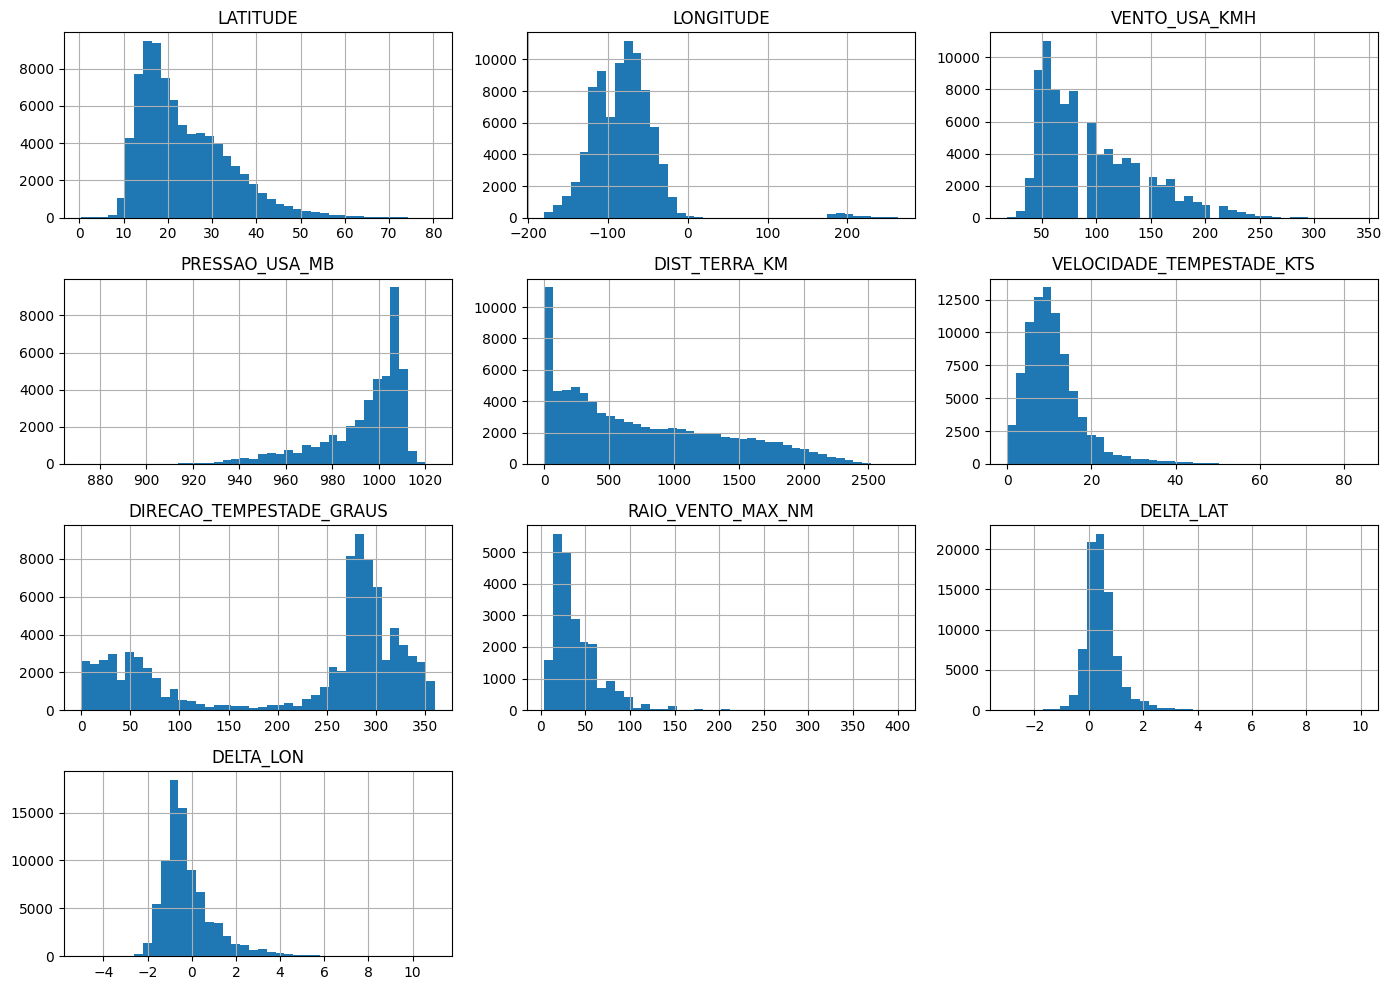

In [7]:
# Histogramas das principais variáveis
df[variaveis_interesse].hist(figsize=(14, 10), bins=40)
plt.tight_layout()
plt.show()

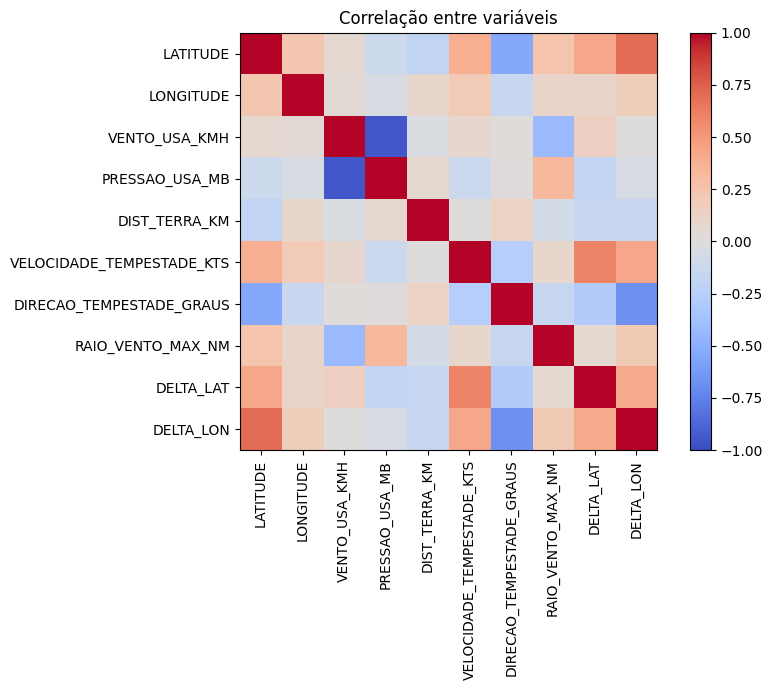

In [8]:
# Matriz de correlação entre variáveis numéricas
corr = df[variaveis_interesse].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlação entre variáveis')
plt.tight_layout()
plt.show()

In [9]:
# Mapa de trajetórias (amostra de tempestades) com Plotly
amostra_ids = df['ID'].unique()[:30]
df_amostra = df[df['ID'].isin(amostra_ids)]

fig = px.line_geo(
    df_amostra, lat='LATITUDE', lon='LONGITUDE', color='ID',
    title='Amostra de trajetórias de furacões (IBTrACS-USA)'
)
fig.show()

## 6. Análise de Componentes Principais (PCA)
Uso exploratório para investigar correlações, redundâncias e padrões entre as
variáveis meteorológicas e espaciais.

PC1: 29.7% (acumulado: 29.7%)
PC2: 25.5% (acumulado: 55.2%)
PC3: 15.9% (acumulado: 71.0%)
PC4: 11.4% (acumulado: 82.4%)
PC5: 10.6% (acumulado: 93.0%)
PC6: 6.3% (acumulado: 99.3%)
PC7: 0.7% (acumulado: 100.0%)


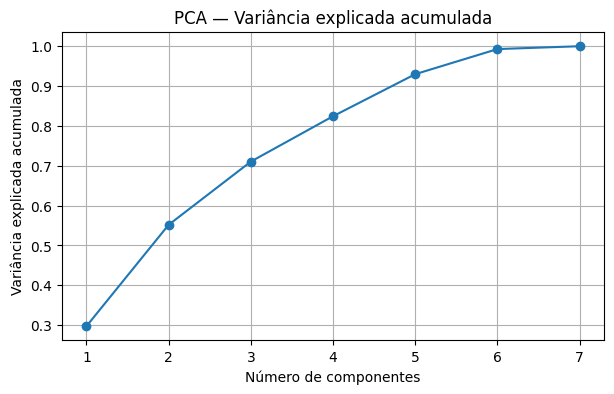

In [10]:
colunas_pca = [
    'LATITUDE', 'LONGITUDE', 'VENTO_USA_KMH', 'PRESSAO_USA_MB',
    'DIST_TERRA_KM', 'VELOCIDADE_TEMPESTADE_KTS', 'DIRECAO_TEMPESTADE_GRAUS'
]

df_pca = df[colunas_pca].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

pca = PCA()
componentes = pca.fit_transform(X_scaled)

variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

for i, (v, va) in enumerate(zip(variancia_explicada, variancia_acumulada), start=1):
    print(f"PC{i}: {v*100:.1f}% (acumulado: {va*100:.1f}%)")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA — Variância explicada acumulada')
plt.grid(True)
plt.show()

## 7. Janelas temporais e divisão treino/teste
Divisão **intra-trajetória**: para cada tempestade, os últimos `h` registros vão para
teste (horizonte de previsão) e os anteriores para treino — preservando a ordem
cronológica e evitando data leakage (seção 3.5 do artigo).

O conjunto de teste inclui o **contexto** (janela de entrada) além do horizonte a
prever, para garantir que dê para montar ao menos uma janela sem misturar dados de
treino como alvo.

In [11]:
HORIZONTE_PREVISAO = 4   # h — quantidade de passos futuros reservados para teste
TAMANHO_JANELA = 8        # quantos passos anteriores o modelo enxerga para prever o próximo

def dividir_intra_trajetoria(df, coluna_id='ID', horizonte=HORIZONTE_PREVISAO, tamanho_janela=TAMANHO_JANELA):
    """Retorna (df_treino, df_teste) respeitando a ordem cronológica por trajetória.
    O teste inclui o contexto (janela) + horizonte, para que dê pra montar ao menos
    uma janela de previsão sem misturar dados de treino como alvo."""
    contexto_necessario = tamanho_janela + horizonte
    treino_partes, teste_partes = [], []
    for _, grupo in df.groupby(coluna_id):
        grupo = grupo.sort_values('DATA_HORA')
        if len(grupo) <= contexto_necessario:
            continue  # trajetória curta demais para gerar teste com contexto suficiente
        treino_partes.append(grupo.iloc[:-horizonte])
        teste_partes.append(grupo.iloc[-contexto_necessario:])
    return pd.concat(treino_partes).reset_index(drop=True), pd.concat(teste_partes).reset_index(drop=True)

df_treino, df_teste = dividir_intra_trajetoria(df)
print(f"Registros de treino: {len(df_treino):,}")
print(f"Registros de teste : {len(df_teste):,}")

Registros de treino: 71,040
Registros de teste : 31,788


In [12]:
COLUNAS_ENTRADA = ['LATITUDE', 'LONGITUDE', 'VENTO_USA_KMH', 'PRESSAO_USA_MB',
                    'DIRECAO_TEMPESTADE_GRAUS', 'DIST_TERRA_KM']
COLUNAS_ALVO = ['DELTA_LAT', 'DELTA_LON']

df_treino_modelo = df_treino.dropna(subset=COLUNAS_ENTRADA + COLUNAS_ALVO).copy()
df_teste_modelo  = df_teste.dropna(subset=COLUNAS_ENTRADA + COLUNAS_ALVO).copy()

# Normalização — ajustada SÓ no treino, para não vazar informação do teste
scaler_entrada = StandardScaler()
df_treino_modelo[COLUNAS_ENTRADA] = scaler_entrada.fit_transform(df_treino_modelo[COLUNAS_ENTRADA])
df_teste_modelo[COLUNAS_ENTRADA]  = scaler_entrada.transform(df_teste_modelo[COLUNAS_ENTRADA])

def gerar_janelas(df, colunas_entrada, colunas_alvo, coluna_id='ID', tamanho_janela=TAMANHO_JANELA):
    """Gera janelas deslizantes (X, y, ids) por trajetória, sem misturar trajetórias diferentes."""
    X, y, ids = [], [], []
    for id_tempestade, grupo in df.groupby(coluna_id):
        grupo = grupo.sort_values('DATA_HORA')
        dados_entrada = grupo[colunas_entrada].values
        dados_alvo = grupo[colunas_alvo].values
        for i in range(len(grupo) - tamanho_janela):
            X.append(dados_entrada[i:i + tamanho_janela])
            y.append(dados_alvo[i + tamanho_janela])
            ids.append(id_tempestade)
    return np.array(X), np.array(y), np.array(ids)

X_treino, y_treino, ids_treino = gerar_janelas(df_treino_modelo, COLUNAS_ENTRADA, COLUNAS_ALVO)
X_teste, y_teste, ids_teste = gerar_janelas(df_teste_modelo, COLUNAS_ENTRADA, COLUNAS_ALVO)

print(f"X_treino: {X_treino.shape}, y_treino: {y_treino.shape}")
print(f"X_teste : {X_teste.shape}, y_teste : {y_teste.shape}")

X_treino: (24075, 8, 6), y_treino: (24075, 2)
X_teste : (4781, 8, 6), y_teste : (4781, 2)


## 8. Modelagem preditiva (LSTM)
Modelo baseline com camadas LSTM, prevendo Δlat/Δlon a partir da janela temporal.

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_treino.shape[2]
n_saidas = y_treino.shape[1]

modelo = Sequential([
    Input(shape=(TAMANHO_JANELA, n_features)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_saidas)
])

modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,322 (79.38 KB)

 Trainable params: 20,322 (79.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3743 - mae: 0.4236 - val_loss: 0.3089 - val_mae: 0.3872
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2945 - mae: 0.3711 - val_loss: 0.2728 - val_mae: 0.3505
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2645 - mae: 0.3453 - val_loss: 0.2395 - val_mae: 0.3288
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2455 - mae: 0.3301 - val_loss: 0.2353 - val_mae: 0.3230
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2287 - mae: 0.3171 - val_loss: 0.2179 - val_mae: 0.3102
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2132 - mae: 0.3051 - val_loss: 0.1963 - val_mae: 0.2900
Epoch 7/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2026 - mae: 0.2974 - val_loss: 0.1844 - val_mae: 0.2853
Epoch 8/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1927 - mae: 0.2900 - val_loss: 0.1946 - val_mae: 0.2907
Epoch 9/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

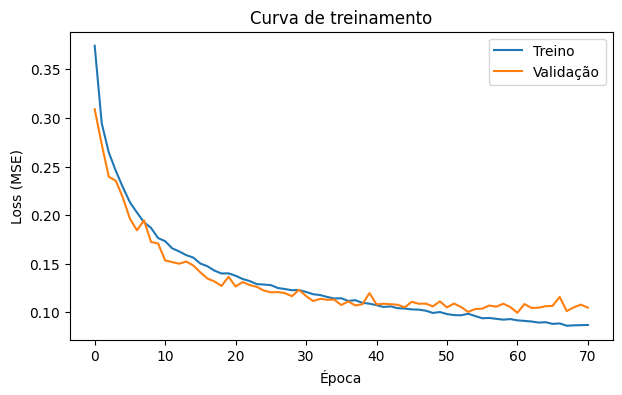

In [14]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

historico = modelo.fit(
    X_treino, y_treino,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(7, 4))
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Curva de treinamento')
plt.show()

## 9. Busca de hiperparâmetros (Random Search)
Exploração de combinações de hiperparâmetros (unidades ocultas, dropout, taxa de
aprendizado), selecionando a configuração com menor RRMSE — avaliado em um conjunto
de **validação separado do treino**, para não enviesar a seleção (seção 3.6 do artigo).

In [15]:
import random

def rrmse(y_real, y_previsto):
    erro_quadratico = np.mean((y_real - y_previsto) ** 2)
    return np.sqrt(erro_quadratico) / np.mean(np.abs(y_real)) * 100

espaco_busca = {
    'unidades_lstm': [32, 64, 128],
    'dropout': [0.1, 0.2, 0.3],
    'taxa_aprendizado': [0.001, 0.0005, 0.0001],
}

N_TENTATIVAS = 5  # aumentar conforme tempo/recursos disponíveis

# Separa uma fatia de validação fixa para avaliar as tentativas de forma justa
# (evita medir o RRMSE em cima dos mesmos dados usados no treino)
n_val = int(0.2 * len(X_treino))
indices_val = np.random.choice(len(X_treino), n_val, replace=False)
mascara_val = np.zeros(len(X_treino), dtype=bool)
mascara_val[indices_val] = True

X_treino_busca, y_treino_busca = X_treino[~mascara_val], y_treino[~mascara_val]
X_val_busca, y_val_busca = X_treino[mascara_val], y_treino[mascara_val]

melhores_resultados = []

for tentativa in range(N_TENTATIVAS):
    config = {chave: random.choice(valores) for chave, valores in espaco_busca.items()}

    modelo_busca = Sequential([
        Input(shape=(TAMANHO_JANELA, n_features)),
        LSTM(config['unidades_lstm']),
        Dropout(config['dropout']),
        Dense(32, activation='relu'),
        Dense(n_saidas)
    ])
    otimizador = tf.keras.optimizers.Adam(learning_rate=config['taxa_aprendizado'])
    modelo_busca.compile(optimizer=otimizador, loss='mse')

    modelo_busca.fit(
        X_treino_busca, y_treino_busca, validation_data=(X_val_busca, y_val_busca),
        epochs=30, batch_size=64, verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    y_pred_val = modelo_busca.predict(X_val_busca, verbose=0)
    erro_rrmse = rrmse(y_val_busca, y_pred_val)

    melhores_resultados.append({**config, 'rrmse': erro_rrmse})
    print(f"Tentativa {tentativa + 1}: {config} -> RRMSE={erro_rrmse:.2f}%")

melhor_config = min(melhores_resultados, key=lambda r: r['rrmse'])
print(f"\nMelhor configuração: {melhor_config}")

Tentativa 1: {'unidades_lstm': 64, 'dropout': 0.3, 'taxa_aprendizado': 0.001} -> RRMSE=49.40%
Tentativa 2: {'unidades_lstm': 128, 'dropout': 0.1, 'taxa_aprendizado': 0.0001} -> RRMSE=63.81%
Tentativa 3: {'unidades_lstm': 32, 'dropout': 0.2, 'taxa_aprendizado': 0.0005} -> RRMSE=55.10%
Tentativa 4: {'unidades_lstm': 64, 'dropout': 0.1, 'taxa_aprendizado': 0.001} -> RRMSE=48.00%
Tentativa 5: {'unidades_lstm': 128, 'dropout': 0.3, 'taxa_aprendizado': 0.0001} -> RRMSE=64.48%

Melhor configuração: {'unidades_lstm': 64, 'dropout': 0.1, 'taxa_aprendizado': 0.001, 'rrmse': np.float64(48.003670443882896)}


## 10. Avaliação de desempenho
RRMSE e MAPE calculados de duas formas complementares:

- **Sobre a posição absoluta reconstruída** — comparável com um baseline de
  persistência (assume que o furacão não se move). Tende a parecer "bom demais"
  porque a última posição conhecida (que já está correta) domina a magnitude do erro.
- **Sobre o Δlat/Δlon diretamente** — mais honesta sobre a capacidade real do modelo,
  mas mais instável (RRMSE/MAPE dividem pela média do valor real, que é próxima de
  zero para os deltas). Por isso também é reportado o **MAE em graus**, mais estável
  e mais comparável com a literatura correlata (ex. Bose et al. 2022).

In [16]:
def classificar_rrmse(valor):
    if valor < 10:
        return 'Excelente'
    elif valor < 20:
        return 'Bom'
    elif valor < 30:
        return 'Aceitável'
    return 'Insatisfatório'

def rrmse(y_real, y_previsto):
    erro_quadratico = np.mean((y_real - y_previsto) ** 2)
    return np.sqrt(erro_quadratico) / np.mean(np.abs(y_real)) * 100

def mape(y_real, y_previsto):
    mascara = np.abs(y_real) > 1e-6
    return np.mean(np.abs((y_real[mascara] - y_previsto[mascara]) / y_real[mascara])) * 100

def prever_horizonte_teste(id_tempestade, df_original, modelo, scaler, colunas_entrada,
                             tamanho_janela=TAMANHO_JANELA, horizonte=HORIZONTE_PREVISAO):
    """Reproduz exatamente a divisão da seção 3.5: contexto = registros imediatamente
    anteriores ao horizonte de teste; previsão recursiva dos h passos finais,
    comparados às posições reais desses mesmos passos."""
    grupo = df_original[df_original['ID'] == id_tempestade].sort_values('DATA_HORA').reset_index(drop=True)
    n = len(grupo)
    if n <= tamanho_janela + horizonte:
        return None

    dados = grupo[colunas_entrada].values
    posicoes = grupo[['LATITUDE', 'LONGITUDE']].values
    idx_lat = colunas_entrada.index('LATITUDE')
    idx_lon = colunas_entrada.index('LONGITUDE')

    fim_contexto = n - horizonte
    inicio_contexto = fim_contexto - tamanho_janela
    janela_atual = scaler.transform(pd.DataFrame(dados[inicio_contexto:fim_contexto], columns=colunas_entrada))

    posicao_atual = posicoes[fim_contexto - 1].copy()
    posicao_baseline = posicao_atual.copy()  # baseline de persistência: nunca muda
    posicoes_reais_futuras = posicoes[fim_contexto:n]
    posicoes_previstas = []

    for passo in range(horizonte):
        entrada = janela_atual.reshape(1, tamanho_janela, len(colunas_entrada))
        delta_previsto = modelo.predict(entrada, verbose=0)[0]
        posicao_atual = posicao_atual + delta_previsto
        posicoes_previstas.append(posicao_atual.copy())

        indice_futuro = fim_contexto + passo
        proximo_registro = dados[indice_futuro].copy()
        proximo_registro[idx_lat] = posicao_atual[0]
        proximo_normalizado = scaler.transform(pd.DataFrame(proximo_registro.reshape(1, -1), columns=colunas_entrada))[0]
        janela_atual = np.vstack([janela_atual[1:], proximo_normalizado])

    posicoes_baseline = np.tile(posicao_baseline, (horizonte, 1))
    return posicoes_reais_futuras, np.array(posicoes_previstas), posicoes_baseline

In [17]:
posicoes_reais_todas, posicoes_previstas_todas, posicoes_baseline_todas = [], [], []

for id_tempestade in df_teste['ID'].unique():
    resultado = prever_horizonte_teste(id_tempestade, df, modelo, scaler_entrada, COLUNAS_ENTRADA)
    if resultado is None:
        continue
    reais, previstas, baseline = resultado
    posicoes_reais_todas.append(reais)
    posicoes_previstas_todas.append(previstas)
    posicoes_baseline_todas.append(baseline)

posicoes_reais_todas = np.vstack(posicoes_reais_todas)
posicoes_previstas_todas = np.vstack(posicoes_previstas_todas)
posicoes_baseline_todas = np.vstack(posicoes_baseline_todas)

erro_rrmse = rrmse(posicoes_reais_todas, posicoes_previstas_todas)
erro_mape = mape(posicoes_reais_todas, posicoes_previstas_todas)
erro_rrmse_baseline = rrmse(posicoes_reais_todas, posicoes_baseline_todas)
erro_mape_baseline = mape(posicoes_reais_todas, posicoes_baseline_todas)

print(f"Horizonte de previsão: h={HORIZONTE_PREVISAO} passos ({HORIZONTE_PREVISAO*6}h)")
print(f"Trajetórias avaliadas: {len(posicoes_reais_todas) // HORIZONTE_PREVISAO}")
print()
print(f"RRMSE baseline (persistência): {erro_rrmse_baseline:.2f}%")
print(f"MAPE  baseline (persistência): {erro_mape_baseline:.2f}%")
print()
print(f"RRMSE modelo LSTM: {erro_rrmse:.2f}% ({classificar_rrmse(erro_rrmse)})")
print(f"MAPE  modelo LSTM: {erro_mape:.2f}%")

Horizonte de previsão: h=4 passos (24h)
Trajetórias avaliadas: 2649

RRMSE baseline (persistência): 6.37%
MAPE  baseline (persistência): 7.29%

RRMSE modelo LSTM: 4.95% (Excelente)
MAPE  modelo LSTM: 4.99%


In [18]:
def distancia_haversine_km(lat1, lon1, lat2, lon2):
    """Distância aproximada em km entre dois pontos (lat/lon em graus)."""
    R = 6371.0
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

erro_km_modelo = distancia_haversine_km(
    posicoes_reais_todas[:, 0], posicoes_reais_todas[:, 1],
    posicoes_previstas_todas[:, 0], posicoes_previstas_todas[:, 1]
)
erro_km_baseline = distancia_haversine_km(
    posicoes_reais_todas[:, 0], posicoes_reais_todas[:, 1],
    posicoes_baseline_todas[:, 0], posicoes_baseline_todas[:, 1]
)

print(f"Erro médio de posição — LSTM     : {erro_km_modelo.mean():.1f} km  (mediana: {np.median(erro_km_modelo):.1f} km)")
print(f"Erro médio de posição — baseline : {erro_km_baseline.mean():.1f} km  (mediana: {np.median(erro_km_baseline):.1f} km)")

# Erro por passo do horizonte (útil pra ver como o erro cresce com o tempo de previsão)
n_trajetorias = len(posicoes_reais_todas) // HORIZONTE_PREVISAO
erro_km_por_passo = erro_km_modelo.reshape(n_trajetorias, HORIZONTE_PREVISAO)
for passo in range(HORIZONTE_PREVISAO):
    horas = (passo + 1) * 6
    print(f"  +{horas}h: erro médio {erro_km_por_passo[:, passo].mean():.1f} km")

Erro médio de posição — LSTM     : 243.8 km  (mediana: 146.8 km)
Erro médio de posição — baseline : 363.7 km  (mediana: 267.7 km)
  +6h: erro médio 95.4 km
  +12h: erro médio 191.5 km
  +18h: erro médio 291.0 km
  +24h: erro médio 397.2 km


### 10.1 Visualização: trajetória real vs. prevista (horizonte de teste)
Mesma lógica de previsão recursiva usada na Etapa 10: o modelo lê o contexto
(`TAMANHO_JANELA` passos imediatamente antes do horizonte de teste) e prevê
recursivamente os `HORIZONTE_PREVISAO` passos finais — os mesmos que entram no
cálculo de RRMSE/MAPE. O histórico anterior ao contexto é mostrado só para dar
noção da trajetória completa da tempestade.

In [19]:
def plotar_trajetoria_horizonte(id_tempestade, df_original, modelo, scaler, colunas_entrada, ax,
                                  tamanho_janela=TAMANHO_JANELA, horizonte=HORIZONTE_PREVISAO):
    """Desenha a trajetória histórica completa (contexto) e compara a posição real
    vs. prevista apenas nos h passos de teste — mesma lógica de prever_horizonte_teste."""
    resultado = prever_horizonte_teste(id_tempestade, df_original, modelo, scaler, colunas_entrada,
                                         tamanho_janela, horizonte)
    if resultado is None:
        return False

    reais_futuras, previstas, _ = resultado

    grupo = df_original[df_original['ID'] == id_tempestade].sort_values('DATA_HORA').reset_index(drop=True)
    posicoes_completas = grupo[['LATITUDE', 'LONGITUDE']].values
    fim_contexto = len(grupo) - horizonte

    # Histórico completo até o fim do contexto (o que o modelo "leu")
    ax.plot(posicoes_completas[:fim_contexto, 1], posicoes_completas[:fim_contexto, 0],
             'o-', color='tab:blue', markersize=3, label='Real (contexto)')
    # Continuação real no horizonte de teste
    ax.plot(reais_futuras[:, 1], reais_futuras[:, 0],
             'o-', color='tab:blue', markersize=3, alpha=0.5, label='Real (horizonte h)')
    ax.plot(posicoes_completas[fim_contexto - 1, 1], posicoes_completas[fim_contexto - 1, 0],
             's', color='black', markersize=6, label='Fim do contexto')
    # Previsão recursiva apenas para o horizonte h (mesmo cálculo da avaliação)
    ax.plot(previstas[:, 1], previstas[:, 0],
             'o--', color='tab:red', markersize=3, label='Prevista (horizonte h)')

    ax.set_title(id_tempestade, fontsize=9)
    ax.tick_params(labelsize=7)
    return True

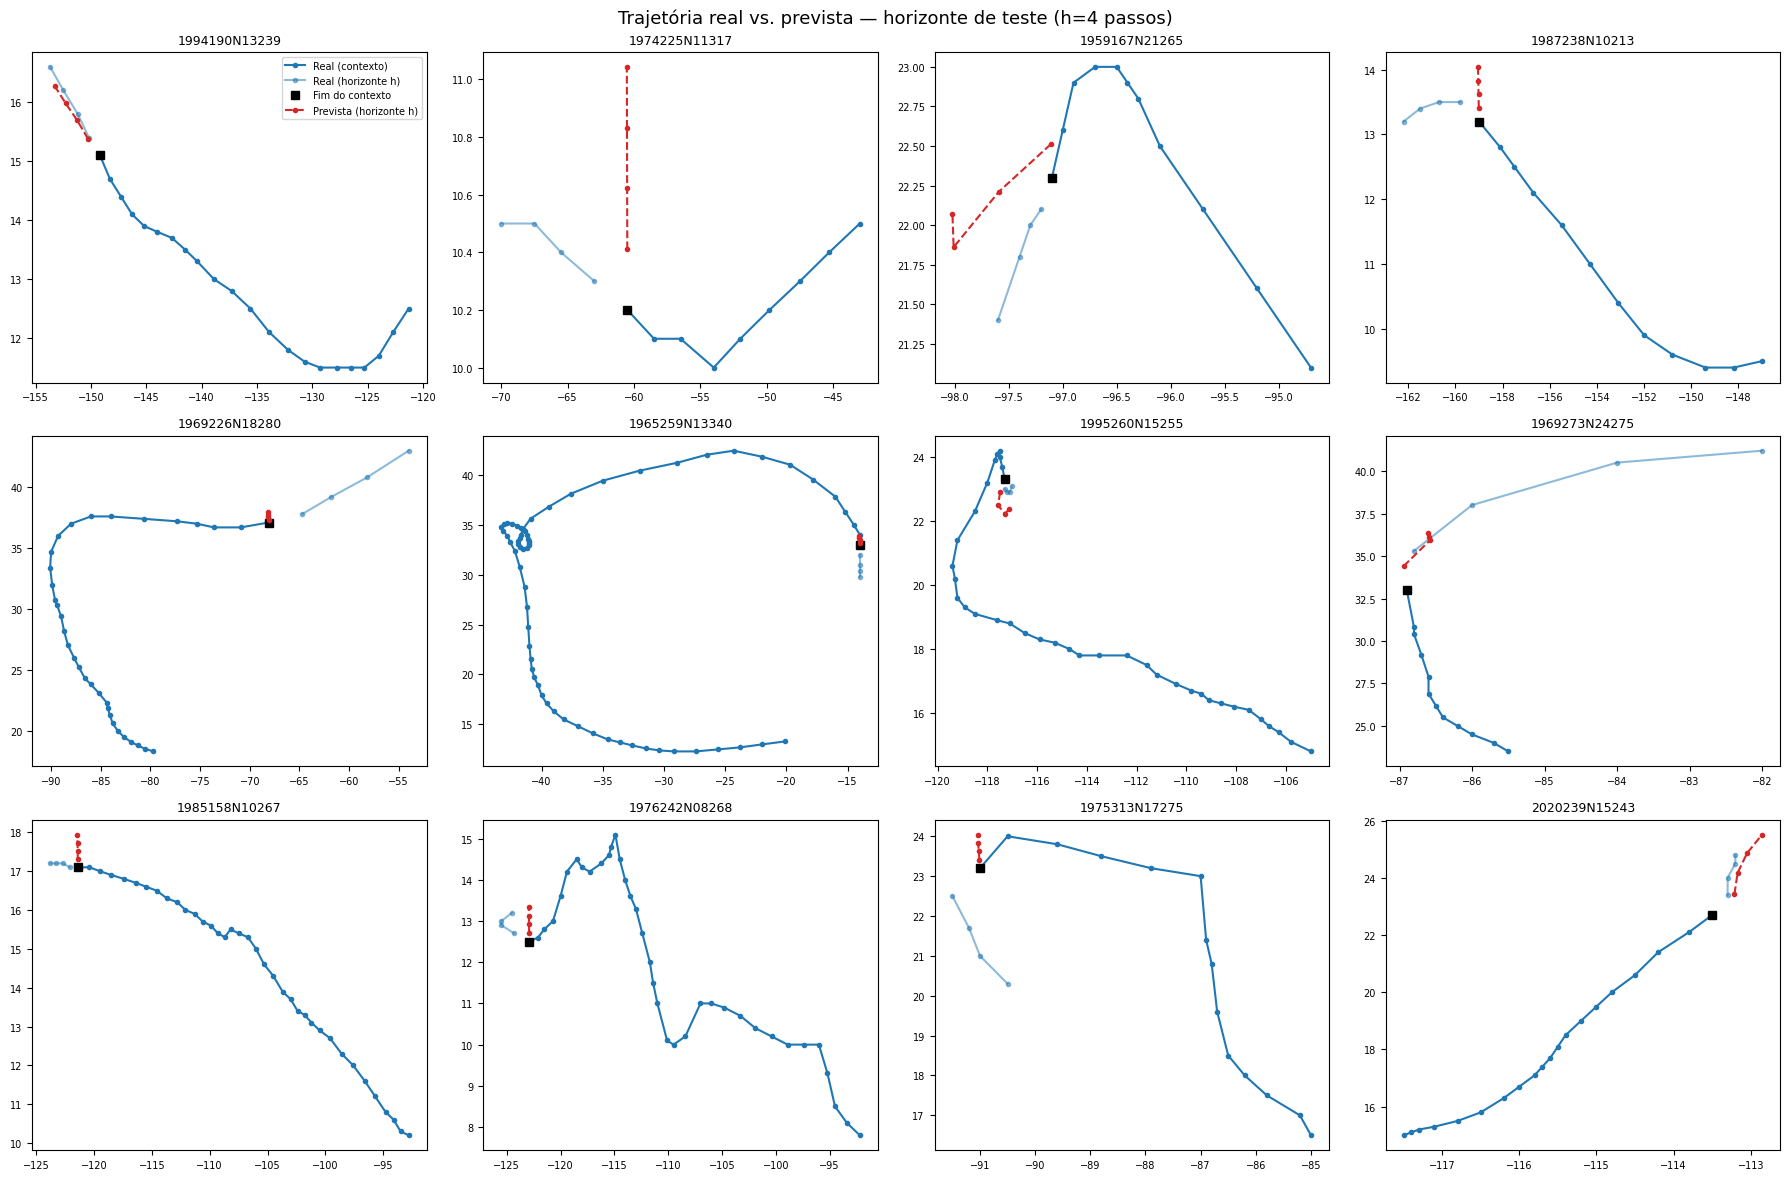

In [20]:
np.random.seed(42)
ids_disponiveis = df_teste['ID'].unique()
n_tempestades = min(12, len(ids_disponiveis))
ids_amostra = np.random.choice(ids_disponiveis, size=n_tempestades, replace=False)

fig, eixos = plt.subplots(3, 4, figsize=(18, 12))
eixos = eixos.flatten()

primeiro_valido = None
for ax, id_tempestade in zip(eixos, ids_amostra):
    ok = plotar_trajetoria_horizonte(id_tempestade, df, modelo, scaler_entrada, COLUNAS_ENTRADA, ax)
    if not ok:
        ax.set_visible(False)
    elif primeiro_valido is None:
        primeiro_valido = ax

if primeiro_valido is not None:
    primeiro_valido.legend(fontsize=7, loc='best')

plt.suptitle(f'Trajetória real vs. prevista — horizonte de teste (h={HORIZONTE_PREVISAO} passos)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Interpretabilidade (SHAP)
Análise da contribuição de cada variável meteorológica nas predições do modelo LSTM,
usando `KernelExplainer` (model-agnostic) — `DeepExplainer` e `GradientExplainer`
apresentam incompatibilidade conhecida com o grafo de gradientes de LSTMs em builds
recentes do TensorFlow/Keras.

c:\Users\dorfb\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

100%|██████████| 20/20 [00:03<00:00,  5.30it/s]


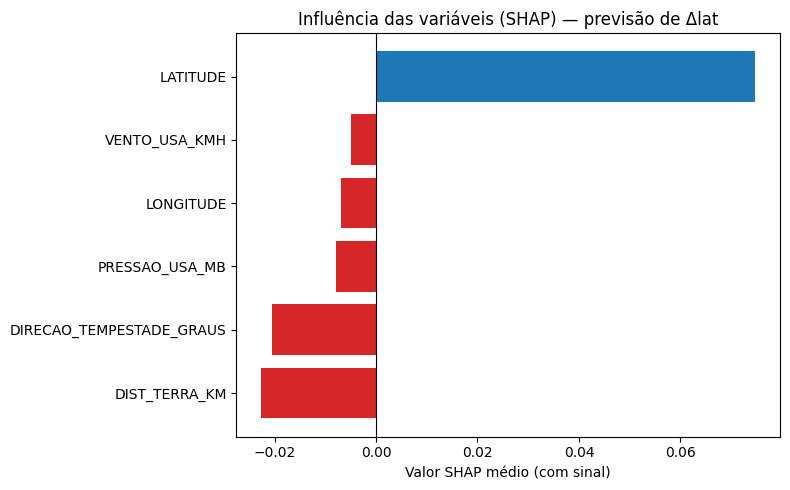

In [21]:
import shap

def modelo_predict_flat(X_flat):
    """Recebe janelas achatadas e devolve a previsão de DELTA_LAT."""
    X_reshaped = X_flat.reshape(-1, TAMANHO_JANELA, len(COLUNAS_ENTRADA))
    return modelo.predict(X_reshaped, verbose=0)[:, 0]  # 0 = DELTA_LAT

n_background = 30   # amostras de referência
n_explicar = 20      # amostras a explicar (mantenha baixo — cada uma custa várias predições)

indices_bg = np.random.choice(X_treino.shape[0], n_background, replace=False)
background_flat = X_treino[indices_bg].reshape(n_background, -1)

amostra_explicar = X_teste[:n_explicar]
amostra_explicar_flat = amostra_explicar.reshape(n_explicar, -1)

explicador = shap.KernelExplainer(modelo_predict_flat, background_flat)
valores_shap = explicador.shap_values(amostra_explicar_flat, nsamples=100)

valores_shap_reshaped = np.array(valores_shap).reshape(n_explicar, TAMANHO_JANELA, len(COLUNAS_ENTRADA))

# Sem abs() — preserva o sinal (influência positiva ou negativa)
shap_medio_com_sinal = valores_shap_reshaped.mean(axis=(0, 1))

ordem = np.argsort(shap_medio_com_sinal)
variaveis_ordenadas = np.array(COLUNAS_ENTRADA)[ordem]
valores_ordenados = shap_medio_com_sinal[ordem]
cores = ['tab:red' if v < 0 else 'tab:blue' for v in valores_ordenados]

plt.figure(figsize=(8, 5))
plt.barh(variaveis_ordenadas, valores_ordenados, color=cores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Valor SHAP médio (com sinal)')
plt.title('Influência das variáveis (SHAP) — previsão de Δlat')
plt.tight_layout()
plt.show()